Task 1: Exploratory Data Analysis (EDA) (2 Marks)
• Load the dataset using sklearn.datasets.fetch_openml(data_id=41554). You can also
download the dataset from the link provided.
• Display the first 5 rows and summary statistics.
• Visualize the correlation between different metals (e.g., Copper vs. Cadmium) using a
scatter plot.


Task 2: Data Cleaning & Transformation (2 Marks)
• Select Cadmium as the target variable (Y) and other metals (Copper, Lead, Zinc, etc.) as
features (X).
• Generate Polynomial Features (degree 2 or 3) to model non-linear chemical interactions.
• Apply Standard Scaling to the features.


Task 3: Model Building (2 Marks)
• Split the data into training and testing sets (80/20).
• Train a Standard Multiple Linear Regression model.
• Train Ridge and Lasso Regression models with a default alpha (alpha=1.0).


Task 4: Model Evaluation (2 Marks)
• Predict the test data for all three models.Calculate and compare the Root Mean Squared
Error (RMSE) and R2 Score for Linear, Ridge, and Lasso.
• Observe the coefficient weights for each model.
• Identify which features Lasso reduced to exactly zero (feature selection).
• Discuss which model performed best and why regularization was necessary.

Task 1: Exploratory Data Analysis (EDA) 

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

In [4]:
data = fetch_openml(data_id=41554, as_frame=True)
df = data.frame
print(df.head())

    Xloc   Yloc  Landuse_1  Landuse_2  Landuse_3  Landuse_4  Rock_1  Rock_2  \
0  2.386  3.077          0          0          1          0       0       0   
1  2.544  1.972          0          1          0          0       0       1   
2  2.807  3.347          0          1          0          0       0       0   
3  4.308  1.933          0          0          1          0       0       1   
4  4.383  1.081          0          0          1          0       0       0   

   Rock_3  Rock_4  Rock_5     Cr     Ni     Pb     Zn     Cd     Co     Cu  
0       1       0       0  38.32  21.32  77.36  92.56  1.740   9.32  25.72  
1       0       0       0  40.20  29.72  77.88  73.56  1.335  10.00  24.76  
2       1       0       0  47.00  21.40  30.80  64.80  1.610  10.60   8.88  
3       0       0       0  43.52  29.72  56.40  90.00  2.150  11.92  22.70  
4       0       0       1  38.52  26.20  66.40  88.40  1.565  16.32  34.32  


In [5]:
print(df.describe())

             Xloc        Yloc   Landuse_1   Landuse_2   Landuse_3   Landuse_4  \
count  359.000000  359.000000  359.000000  359.000000  359.000000  359.000000   
mean     2.963384    2.631769    0.142061    0.228412    0.607242    0.022284   
std      0.980822    1.269089    0.349600    0.420396    0.489045    0.147812   
min      0.491000    0.524000    0.000000    0.000000    0.000000    0.000000   
25%      2.260500    1.510500    0.000000    0.000000    0.000000    0.000000   
50%      3.040000    2.489000    0.000000    0.000000    1.000000    0.000000   
75%      3.674000    3.652000    0.000000    0.000000    1.000000    0.000000   
max      4.920000    5.690000    1.000000    1.000000    1.000000    1.000000   

           Rock_1      Rock_2      Rock_3      Rock_4      Rock_5          Cr  \
count  359.000000  359.000000  359.000000  359.000000  359.000000  359.000000   
mean     0.211699    0.345404    0.247911    0.016713    0.178273   35.017827   
std      0.409083    0.4761

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 359 entries, 0 to 358
Data columns (total 18 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Xloc       359 non-null    float64
 1   Yloc       359 non-null    float64
 2   Landuse_1  359 non-null    int64  
 3   Landuse_2  359 non-null    int64  
 4   Landuse_3  359 non-null    int64  
 5   Landuse_4  359 non-null    int64  
 6   Rock_1     359 non-null    int64  
 7   Rock_2     359 non-null    int64  
 8   Rock_3     359 non-null    int64  
 9   Rock_4     359 non-null    int64  
 10  Rock_5     359 non-null    int64  
 11  Cr         359 non-null    float64
 12  Ni         359 non-null    float64
 13  Pb         359 non-null    float64
 14  Zn         359 non-null    float64
 15  Cd         359 non-null    float64
 16  Co         359 non-null    float64
 17  Cu         359 non-null    float64
dtypes: float64(9), int64(9)
memory usage: 50.6 KB


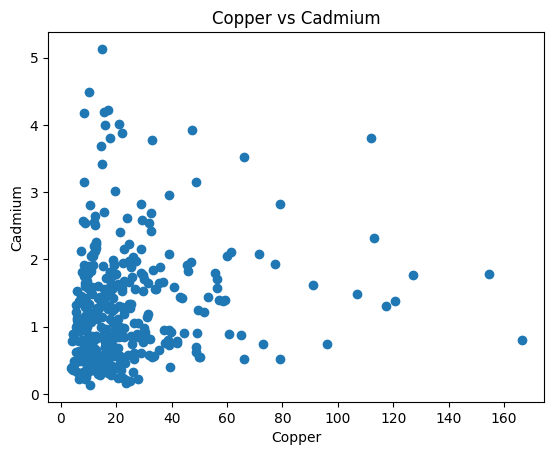

In [8]:
plt.scatter(df['Cu'], df['Cd'])
plt.xlabel("Copper")
plt.ylabel("Cadmium")
plt.title("Copper vs Cadmium")
plt.show()

Task 2: Data Cleaning & Transformation

In [9]:
# Target variable
Y = df['Cd']

# Feature variables
X = df[['Cr','Ni','Pb','Zn','Co','Cu']]

# Polynomial features (non-linear interactions)
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)


In [10]:
# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

Task 3: Model Building

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, Y, test_size=0.2, random_state=42)

In [12]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [13]:
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [14]:
lasso_model = Lasso(alpha=1.0)
lasso_model.fit(X_train, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


Task 4: Model Evaluation

In [15]:
linear_pred = linear_model.predict(X_test)
ridge_pred = ridge_model.predict(X_test)
lasso_pred = lasso_model.predict(X_test)

In [16]:
def evaluate_model(y_test, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(f"{name} RMSE:", rmse)
    print(f"{name} R2 Score:", r2)
    print()

evaluate_model(y_test, linear_pred, "Linear Regression")
evaluate_model(y_test, ridge_pred, "Ridge Regression")
evaluate_model(y_test, lasso_pred, "Lasso Regression")

Linear Regression RMSE: 0.5116333278829153
Linear Regression R2 Score: 0.5965824058551188

Ridge Regression RMSE: 0.49180578313499496
Ridge Regression R2 Score: 0.6272441704312788

Lasso Regression RMSE: 0.8087172166439488
Lasso Regression R2 Score: -0.007930435176925155



In [17]:
print("Linear Coefficients:", linear_model.coef_)
print("Ridge Coefficients:", ridge_model.coef_)
print("Lasso Coefficients:", lasso_model.coef_)

Linear Coefficients: [-5.19615131e-16 -5.60844593e-01  8.41792549e-01  2.51847452e-01
  2.17813323e-01 -4.57415205e-01 -4.84066083e-01  3.46701101e-01
 -1.33354135e-01 -1.19874474e-01  1.47051294e+00 -2.93366555e-01
 -4.06873106e-01 -8.40841520e-01  4.75273808e-01 -9.03623610e-01
  9.25808499e-01  4.41042959e-01  4.48430042e-01 -1.39348654e+00
  9.91609291e-02 -3.73199858e-01  8.28924960e-01 -3.42164118e-01
 -1.91897406e-01  7.89839639e-02  9.66434881e-02  4.73475155e-01]
Ridge Coefficients: [ 0.         -0.36606401  0.60868006  0.18681961  0.31516349 -0.35399247
 -0.41101278  0.32954555 -0.10835066 -0.11547005  0.87572529 -0.21709366
 -0.13546068 -0.50509827  0.25062809 -0.3132743   0.33475336  0.20310607
  0.14901795 -0.66343718  0.07544251 -0.20626031  0.55170253 -0.2371467
 -0.47039441  0.20474069  0.10241469  0.40724008]
Lasso Coefficients: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0.]


In [18]:
zero_features = np.sum(lasso_model.coef_ == 0)
print("Number of features reduced to zero by Lasso:", zero_features)

Number of features reduced to zero by Lasso: 28


Insight got:

Linear regression may suffer from multicollinearity between metals.

Ridge regression reduces coefficient size and stabilizes the model.

Lasso regression performs feature selection by shrinking some coefficients to zero.

Regularization helps improve prediction accuracy and model stability.